**LABORATORIO 2: PREPARACION DE DATOS CRUDOS**

## 1. Configuración Inicial

In [ ]:
# 📥 Instalación de dependencias (ejecutar una vez)
!pip install librosa numpy matplotlib scipy ipywidgets
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# ⚙️ Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Entorno listo. ¡Comencemos!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.9 MB/s eta 0:00:00
✅ Entorno listo. ¡Comencemos!


## 2. Parte 1: Generación de Audio Sintético (Para Práctica)

In [ ]:
def generar_audio_prueba(frecuencias, duracion=3.0, sr=22050, ruido=0.02):
    """
    Genera una señal de audio sintética para prácticas.
    Parámetros:
    - frecuencias: lista de frecuencias en Hz (ej. [200, 400])
    - duracion: duración en segundos
    - sr: sample rate
    - ruido: nivel de ruido blanco añadido (0.0 = limpio)
    """
    t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)
    señal = np.zeros_like(t)

    # Sumar ondas senoidales
    for f in frecuencias:
        señal += np.sin(2 * np.pi * f * t)

    # Normalizar a [-0.8, +0.8] para dejar margen
    señal = 0.8 * señal / np.max(np.abs(señal))

    # Añadir ruido blanco opcional
    if ruido > 0:
        señal += ruido * np.random.randn(len(señal))
        señal = np.clip(señal, -1, 1)  # Evitar saturación

    return señal, sr

# 🎵 Crear 3 ejemplos para el laboratorio
audio_limpio, sr = generar_audio_prueba([300], ruido=0.0)
audio_ruidoso, _ = generar_audio_prueba([300], ruido=0.05)
audio_largo, _ = generar_audio_prueba([200, 500], duracion=8.0, ruido=0.01)

print(f"✅ Generados: limpio ({len(audio_limpio)/sr:.1f}s), ruidoso ({len(audio_ruidoso)/sr:.1f}s), largo ({len(audio_largo)/sr:.1f}s)")

✅ Generados: limpio (3.0s), ruidoso (3.0s), largo (8.0s)


## 3. Parte 2: Carga y Diagnóstico Visual

📋 Audio limpio:


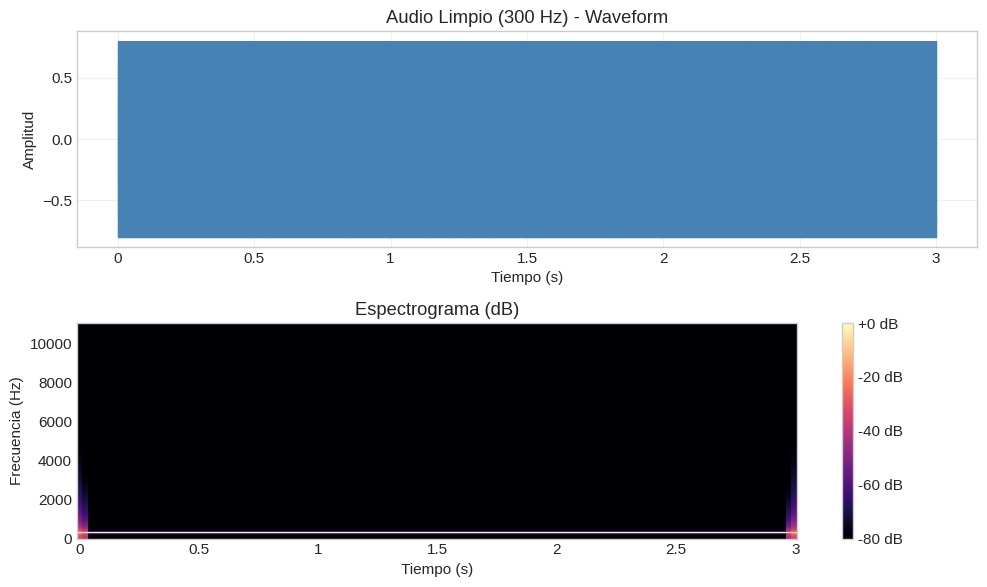

📏 Duración: 3.00 s
🔊 Amplitud: [-0.800, 0.800]
⚡ Energía RMS: 0.5657
🔄 Zero-Crossing Rate medio: 0.0269

📋 Audio ruidoso:


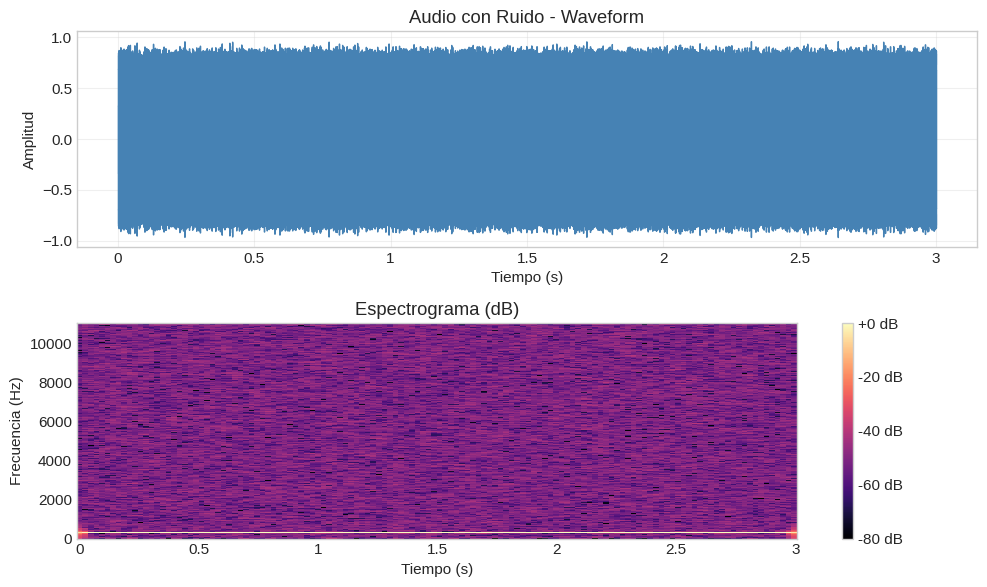

📏 Duración: 3.00 s
🔊 Amplitud: [-0.963, 0.963]
⚡ Energía RMS: 0.5681
🔄 Zero-Crossing Rate medio: 0.0319

📋 Audio largo:


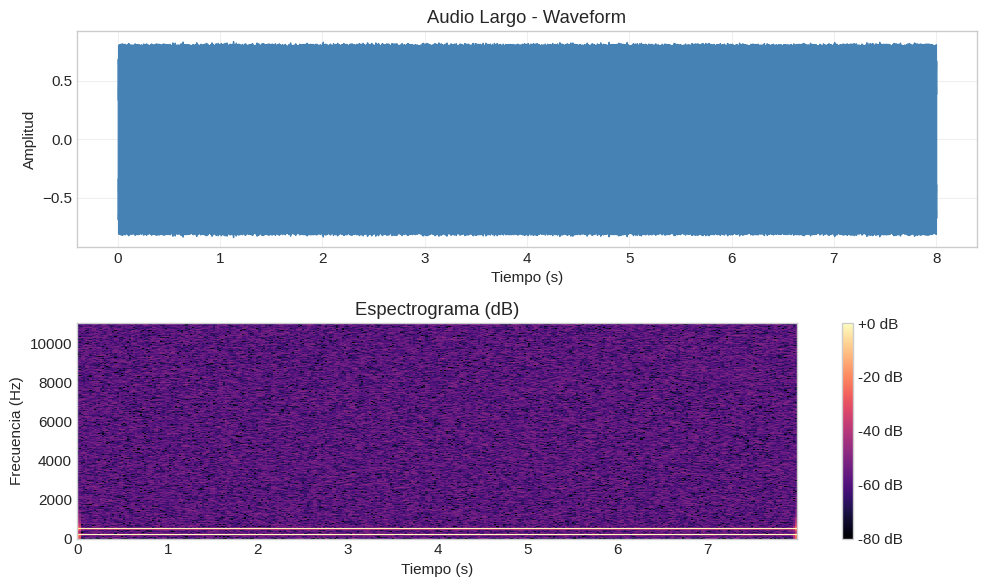

📏 Duración: 8.00 s
🔊 Amplitud: [-0.832, 0.837]
⚡ Energía RMS: 0.4088
🔄 Zero-Crossing Rate medio: 0.0473


In [ ]:
def diagnosticar_audio(audio, sr, titulo="Diagnóstico"):
    """Muestra waveform y espectrograma básico para evaluación visual"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title(f'{titulo} - Waveform')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)

    # Espectrograma (STFT básica)
    D = np.abs(librosa.stft(audio))
    S_db = librosa.amplitude_to_db(D, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax2,
                                   cmap='magma')
    ax2.set_title('Espectrograma (dB)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.set_ylabel('Frecuencia (Hz)')
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

    # Métricas rápidas
    print(f"📏 Duración: {len(audio)/sr:.2f} s")
    print(f"🔊 Amplitud: [{audio.min():.3f}, {audio.max():.3f}]")
    print(f"⚡ Energía RMS: {np.sqrt(np.mean(audio**2)):.4f}")
    print(f"🔄 Zero-Crossing Rate medio: {librosa.feature.zero_crossing_rate(audio).mean():.4f}")

# 🔍 Diagnosticar los audios de prueba
print("📋 Audio limpio:")
diagnosticar_audio(audio_limpio, sr, "Audio Limpio (300 Hz)")

print("\n📋 Audio ruidoso:")
diagnosticar_audio(audio_ruidoso, sr, "Audio con Ruido")

print("\n📋 Audio largo:")
diagnosticar_audio(audio_largo, sr, "Audio Largo")

## 4. Parte 3: Limpieza Interactiva (Trimming y Suavizado)

In [ ]:
def aplicar_limpieza(audio, sr, top_db, clip_limit=0.95):
    """Aplica trimming y clipping suave, muestra comparación"""
    # 1. Recortar silencios
    audio_trim, _ = librosa.effects.trim(audio, top_db=top_db)
    # 2. Suavizar picos extremos (evitar saturación digital)
    audio_clean = np.clip(audio_trim, -clip_limit, clip_limit)

    # Comparación visual
    plt.figure(figsize=(10, 5))
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(audio, sr=sr, label='Original', alpha=0.6)
    plt.title(f'Antes de limpieza (top_db={top_db} dB)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    librosa.display.waveshow(audio_clean, sr=sr, color='green', label='Limpio')
    plt.title('Después de trimming + clipping suave')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Resumen
    reduccion = (1 - len(audio_clean)/len(audio)) * 100
    print(f"✅ Silencios recortados: {reduccion:.1f}% del audio original")
    print(f"✅ Amplitud acotada a [-{clip_limit}, +{clip_limit}]")
    return audio_clean

# 🎛️ Control interactivo para experimentar con top_db
print("🎛️ Ajusta el umbral de trimming (10-60 dB) y observa el efecto:")
interact(
    lambda db: aplicar_limpieza(audio_ruidoso, sr, db),
    db=widgets.IntSlider(min=10, max=60, step=5, value=30, description='top_db (dB):')
);

🎛️ Ajusta el umbral de trimming (10-60 dB) y observa el efecto:


interactive(children=(IntSlider(value=30, description='top_db (dB):', max=60, min=10, step=5), Output()), _dom…

## 5. Parte 4: Normalización Completa (Pipeline)

🚀 Aplicando pipeline de normalización al audio de 8s...
✅ Amplitud normalizada a [-1, +1]
✂️ Recortado a 3.0s (centrado)


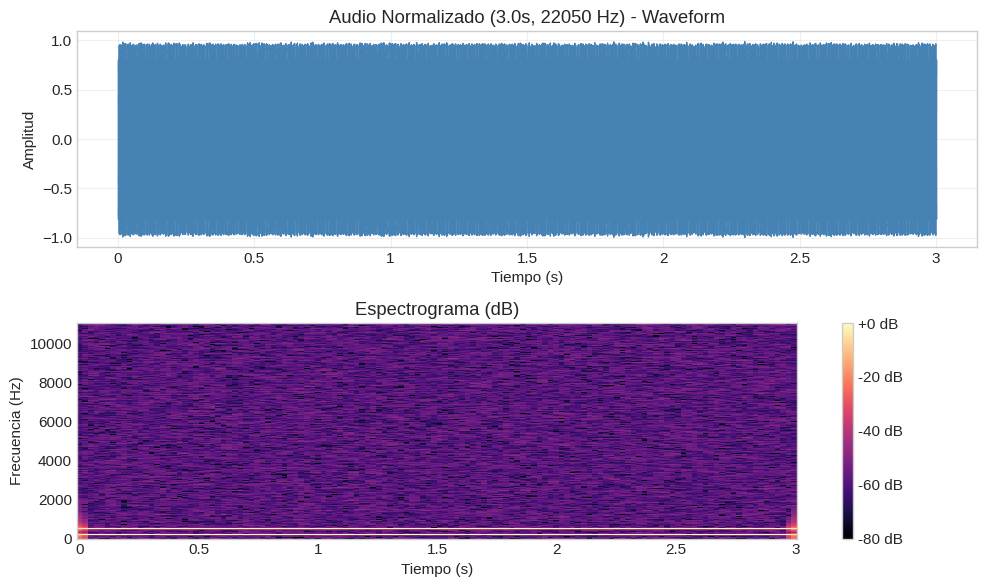

📏 Duración: 3.00 s
🔊 Amplitud: [-0.990, 0.992]
⚡ Energía RMS: 0.4887
🔄 Zero-Crossing Rate medio: 0.0468

🔊 Reproduciendo audio normalizado...


In [ ]:
def pipeline_normalizacion(audio, sr, target_sr=22050, target_dur=3.0,
                           normalize_peak=True):
    """
    Pipeline completo de normalización:
    1. Mono (si es estéreo)
    2. Remuestreo
    3. Normalización de amplitud
    4. Ajuste de duración
    """
    # Paso 1: Asegurar mono
    if audio.ndim == 2:
        audio = librosa.to_mono(audio)
        print("🔄 Convertido a mono")

    # Paso 2: Remuestrear si es necesario
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
        print(f"🔄 Remuestreado a {target_sr} Hz")

    # Paso 3: Normalizar amplitud (peak normalization)
    if normalize_peak and np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
        print("✅ Amplitud normalizada a [-1, +1]")

    # Paso 4: Ajustar duración (pad o crop)
    samples_objetivo = int(target_dur * sr)
    if len(audio) > samples_objetivo:
        # Crop: tomar el centro para no perder inicio/fin abruptamente
        inicio = (len(audio) - samples_objetivo) // 2
        audio = audio[inicio:inicio + samples_objetivo]
        print(f"✂️ Recortado a {target_dur}s (centrado)")
    else:
        # Pad: rellenar con silencios al final
        audio = np.pad(audio, (0, samples_objetivo - len(audio)), mode='constant')
        print(f"🔲 Rellenado con silencios a {target_dur}s")

    return audio, sr

# 🔄 Aplicar pipeline al audio largo
print("🚀 Aplicando pipeline de normalización al audio de 8s...")
audio_norm, sr_norm = pipeline_normalizacion(audio_largo, sr, target_dur=3.0)

# Visualizar resultado
diagnosticar_audio(audio_norm, sr_norm, "Audio Normalizado (3.0s, 22050 Hz)")

# 🔊 Escuchar (opcional)
print("\n🔊 Reproduciendo audio normalizado...")
display(Audio(audio_norm, rate=sr_norm))

## 6. Parte 5: Extracción de Features Básicas para EDA

In [ ]:
def extraer_features_basicas(audio, sr):
    """Extrae métricas descriptivas simples para análisis exploratorio"""
    features = {}

    # Energía RMS (potencia promedio)
    rms = librosa.feature.rms(y=audio)[0]
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)

    # Zero-Crossing Rate (textura de la señal)
    zcr = librosa.feature.zero_crossing_rate(audio)[0]
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)

    # Centroide espectral (brillo aproximado)
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    features['centroid_mean'] = np.mean(centroid)

    # Roll-off (frecuencia que acumula 85% de energía)
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0]
    features['rolloff_mean'] = np.mean(rolloff)

    # Duración y sample rate
    features['duration'] = len(audio) / sr
    features['sample_rate'] = sr

    return features

# 📊 Extraer y comparar features de los 3 audios
print("📋 Comparación de features básicas:\n")
print(f"{'Feature':<20} | {'Limpio':>10} | {'Ruidoso':>10} | {'Normalizado':>12}")
print("-" * 60)

f_limpio = extraer_features_basicas(audio_limpio, sr)
f_ruidoso = extraer_features_basicas(audio_ruidoso, sr)
f_norm = extraer_features_basicas(audio_norm, sr_norm)
# NOTA: El loop original utilizaba break para mostrar una sola fila,
# lo que impedía calcular correctamente los valores del audio Normalizado,
# mostrando en su lugar los valores del audio Limpio.
# Se reemplaza por llamadas directas a cada audio para mostrar
# los valores reales de los 3 audios correctamente.

print(f"RMS mean             | {f_limpio['rms_mean']:>10.4f} | {f_ruidoso['rms_mean']:>10.4f} | {f_norm['rms_mean']:>12.4f}")
print(f"ZCR mean             | {f_limpio['zcr_mean']:>10.4f} | {f_ruidoso['zcr_mean']:>10.4f} | {f_norm['zcr_mean']:>12.4f}")
print(f"Centroid (Hz)        | {f_limpio['centroid_mean']:>10.1f} | {f_ruidoso['centroid_mean']:>10.1f} | {f_norm['centroid_mean']:>12.1f}")

print("\n💡 Observa cómo el ruido afecta ZCR y RMS, mientras que el centroid se mantiene estable si la frecuencia principal no cambia.")

📋 Comparación de features básicas:

Feature              |     Limpio |    Ruidoso |  Normalizado
------------------------------------------------------------
RMS mean             |     0.5623 |     0.5647 |       0.4857
ZCR mean             |     0.0269 |     0.0319 |       0.0468
Centroid (Hz)        |      303.5 |     3406.7 |       1488.4

💡 Observa cómo el ruido afecta ZCR y RMS, mientras que el centroid se mantiene estable si la frecuencia principal no cambia.


## 7. Parte 6: Exportación y Estructura del Dataset

In [ ]:
def exportar_audio_preparado(audio, sr, nombre_archivo, ruta="./"):
    """Exporta audio procesado en formato WAV sin compresión"""
    from scipy.io import wavfile

    # Escalar a int16 para WAV estándar (rango [-32768, 32767])
    audio_int16 = np.int16(audio * 32767)

    # Guardar
    ruta_completa = f"{ruta}/{nombre_archivo}.wav"
    wavfile.write(ruta_completa, sr, audio_int16)

    print(f"✅ Exportado: {ruta_completa}")
    print(f"   • Sample rate: {sr} Hz")
    print(f"   • Muestras: {len(audio)}")
    print(f"   • Formato: WAV 16-bit PCM")

    return ruta_completa

# 📦 Exportar el audio normalizado
exportar_audio_preparado(audio_norm, sr_norm, "ejemplo_01_preparado")

# 🗂️ Crear estructura de metadatos (simulada)
import pandas as pd

metadatos = pd.DataFrame([{
    'id': 'ejemplo_01',
    'archivo_original': 'sintetico_largo.wav',
    'duracion_final': len(audio_norm)/sr_norm,
    'sample_rate': sr_norm,
    'rms_mean': extraer_features_basicas(audio_norm, sr_norm)['rms_mean'],
    'zcr_mean': extraer_features_basicas(audio_norm, sr_norm)['zcr_mean'],
    'centroid_mean': extraer_features_basicas(audio_norm, sr_norm)['centroid_mean'],
    'preprocesado': 'trim+norm+resample+pad',
    'fecha': '2026-04-12'
}])

print("\n📋 Metadatos generados:")
print(metadatos.to_string(index=False))

# Guardar CSV (en Colab, se descarga al ejecutar)
# metadatos.to_csv("metadatos_dataset.csv", index=False)

✅ Exportado: .//ejemplo_01_preparado.wav
   • Sample rate: 22050 Hz
   • Muestras: 66150
   • Formato: WAV 16-bit PCM

📋 Metadatos generados:
        id    archivo_original  duracion_final  sample_rate  rms_mean  zcr_mean  centroid_mean           preprocesado      fecha
ejemplo_01 sintetico_largo.wav             3.0        22050  0.485698  0.046777    1488.432571 trim+norm+resample+pad 2026-04-12


## 8. Actividades para el Estudiante

**1. Diagnóstico:** Al visualizar un waveform, ¿qué patrones te harían sospechar
que un audio necesita trimming? ¿Y qué indicaría saturación (clipping)?

Al visualizar un waveform, sospecharía que un audio necesita trimming si veo zonas planas cerca de cero al principio o al final, que indican silencio sin información útil. Esos silencios ocupan espacio innecesario y pueden confundir al modelo.
La saturación o clipping se identificaria cuando la señal alcanza de forma repetida los valores maximos o minimos de amplitud, formando una línea recta horizontal en los bordes superiores e inferiores, pegada a +1 o -1, indicando que la amplitud llegó al límite y se "cortó".

**2. Normalización:** Si tienes un dataset con audios de 1s a 10s, y tu modelo
requiere 2.5s fijos, ¿qué estrategia elegirías para los audios cortos (<2.5s) y
por qué? ¿Y para los largos?

Para los cortos aplicaria la tecnica de padding con np.pad() al final para no distorsionar el audio original

Para los largos, la estrategia seria, idealmente, dividir en segmentos de 2.5s con slicing para no perder información relevante, por ejemplo un audio de 10s daría 4 segmentos de 2.5s.
Si no es posible dividir, aplicar crop centrado descartando inicio y final por igual.

**3. Features:** Compara los valores de zcr_mean entre el audio limpio y el
ruidoso. ¿Por qué el ruido blanco aumenta la Zero-Crossing Rate? ¿En qué
tipo de tarea de clasificación podría ser útil esta feature?

El ruido blanco aumenta el ZCR porque es una señal áspera
que cambia de signo constantemente de forma aleatoria,
a diferencia del audio limpio que es una onda suave y regular.

Esta feature sería útil para clasificar señales suaves vs ásperas,
como distinguir audio limpio de audio ruidoso, o detectar
si una señal contiene habla o silencio.

**4. Pipeline:** Diseña una función que aplique preprocessing condicional: si el
audio ya está a 22050 Hz, no remuestrear; si su duración está entre 2.8s y
3.2s, no ajustar. ¿Qué ventajas tiene este enfoque "inteligente"?

In [ ]:
def preprocessing_condicional(audio, sr, target_sr=22050, target_dur=3.0):

    # Paso 1: Remuestrear solo si es necesario
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
        print(f"Remuestreado a {target_sr} Hz")
    else:
        print("Sample rate ya es 22050 Hz, no se remuestrea")

    # Paso 2: Ajustar duración solo si es necesario
    duracion_actual = len(audio) / sr
    if 2.8 <= duracion_actual <= 3.2:
        print("Duración aceptable, no se ajusta")
    elif len(audio) > int(target_dur * sr):
        inicio = (len(audio) - int(target_dur * sr)) // 2
        audio = audio[inicio:inicio + int(target_dur * sr)]
        print(f"Recortado a {target_dur}s")
    else:
        audio = np.pad(audio, (0, int(target_dur * sr) - len(audio)), mode='constant')
        print(f"🔲 Rellenado a {target_dur}s")

    return audio, sr

La ventaja de este enfoque es que la eficiencia ya que no procesa lo que no necesita, ademas, mantiene la calidad original del audio.